# Multi-omics integration — metabolomics + RNA-seq with MOFA

Most metabolomics studies that aim for mechanism also collect
transcriptomics on the same samples. The standard unsupervised factor
model for joint analysis is **MOFA+** (Argelaguet 2020): it learns a
small set of latent factors that capture variation *shared* across
modalities plus modality-specific components.

`omicverse` ships MOFA+ via the vendored ``omicverse.external.mofapy2``
plus the ``ov.single.pyMOFA`` trainer wrapper, but the *downstream*
helpers (``pyMOFAART``, ``factor_exact``) are written for
**single-cell** AnnData where each row is a cell. For bulk
metabolomics studies each row is a sample, and those helpers are the
wrong fit.

``ov.metabol.run_mofa`` is the metabolomics-friendly bridge: take a
dict of sample-aligned AnnData views, drive training, return the
factor × sample matrix.

This tutorial uses **synthetic paired data** (30 samples × 20
metabolites + 30 samples × 80 genes) with a planted shared factor so
you can see MOFA+ recover it. For your real study you would pass your
existing metabolomics AnnData together with your RNA-seq AnnData.


## 0 — Setup & simulated paired data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from anndata import AnnData
import omicverse as ov

rng = np.random.default_rng(0)
n = 30
n_m = 20
n_g = 80

# Shared latent signal — some samples are high, others low
shared = rng.standard_normal(n)
# Metabolite view — first 8 metabolites load on the shared factor
X_m = rng.standard_normal((n, n_m)) * 0.3
X_m[:, :8] += 1.5 * shared[:, None]
# Gene view — first 30 genes load on the shared factor (higher-dim view)
X_g = rng.standard_normal((n, n_g)) * 0.3
X_g[:, :30] += 1.0 * shared[:, None]

samples = [f's{i:02d}' for i in range(n)]
obs = pd.DataFrame(index=samples)
adata_m = AnnData(X=X_m, obs=obs.copy(),
                  var=pd.DataFrame(index=[f'met{i}' for i in range(n_m)]))
adata_r = AnnData(X=X_g, obs=obs.copy(),
                  var=pd.DataFrame(index=[f'gene{i}' for i in range(n_g)]))
adata_m.shape, adata_r.shape


((30, 20), (30, 80))

## 1 — Train MOFA+

Sample ordering **must** match across views — MOFA+ concatenates by
position, and ``run_mofa`` validates this and raises a helpful error
if it doesn't. Training on 30 samples × 100 features takes <5 s.


In [2]:
factors = ov.metabol.run_mofa(
    views={'metabol': adata_m, 'rna': adata_r},
    n_factors=5,
    outfile='mofa_demo.hdf5',
    scale_views=True,
    max_iter=200,
    seed=0,
)
print(f'retained {factors.shape[1]} factor(s) after MOFA+ pruning')
factors.head()


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        


Scaling views to unit variance...

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Successfully loaded view='metabol' group='group0' with N=30 samples and D=20 features...
Successfully loaded view='rna' group='group0' with N=30 samples and D=80 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (metabol): gaussian
- View 1 (rna): gaussian




######################################
## Training the model with seed 0 ##
######################################


ELBO before training: -16211.58 

Iteration 1: time=0.00, ELBO=-4208.27, deltaELBO=12003.310 (74.04156835%), Factors=4


Iteration 2: time=0.00, ELBO=-3502.03, deltaELBO=706.241 (4.35639954%), Factors=3


Iteration 3: time=0.00, ELBO=-3278.36, deltaELBO=223.667 (1.37967140%), Factors=2


...

Iteration 10: time=0.00, ELBO=-3082.25, deltaELBO=0.106 (0.00065633%), Factors=1


Iteration 11: time=0.00, ELBO=-3082.19, deltaELBO=0.060 (0.00036709%), Factors=1


Iteration 12: time=0.00, ELBO=-3082.15, deltaELBO=0.033 (0.00020498%), Factors=1

Converged!



#######################
## Training finished ##
#######################


Saving model in /scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse_guide/docs/Tutorials-metabol/mofa_demo.hdf5...


retained 1 factor(s) after MOFA+ pruning


           F1
s00 -0.694762
s01  0.088217
s02 -2.239374
s03 -0.595385
s04  1.260085

## 2 — Plug the factors back into an AnnData

The returned DataFrame is ``samples × factors``. The standard move is
to attach it as ``obsm['X_mofa']`` so the rest of omicverse (plotting,
clustering) can see the integrated embedding.


In [3]:
adata_m.obsm['X_mofa'] = factors.reindex(adata_m.obs_names).to_numpy()
adata_r.obsm['X_mofa'] = factors.reindex(adata_r.obs_names).to_numpy()
print('metabol AnnData now carries:', list(adata_m.obsm.keys()))


metabol AnnData now carries: ['X_mofa']


## 3 — Recovery of the planted shared factor

Correlate each MOFA factor against the shared signal we planted. At
least one factor should track it closely.


Factor correlation with planted shared signal:
F1    0.998612
dtype: float64


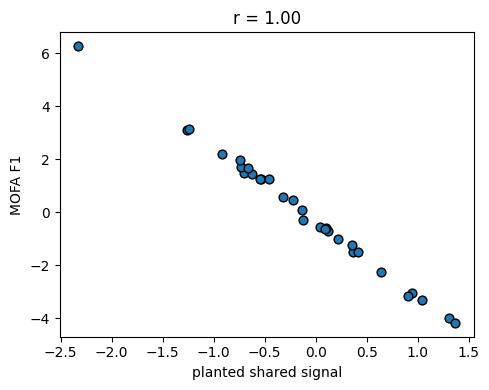

In [4]:
corrs = factors.corrwith(pd.Series(shared, index=samples)).abs()
print('Factor correlation with planted shared signal:')
print(corrs.sort_values(ascending=False))
best = corrs.idxmax()
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(shared, factors[best], color='C0', edgecolor='k', s=40)
ax.set_xlabel('planted shared signal')
ax.set_ylabel(f'MOFA {best}')
ax.set_title(f'r = {corrs[best]:.2f}')
fig.tight_layout()
plt.show()


## 4 — How to use factors downstream

- **Clustering / sub-typing**: apply k-means or hierarchical
  clustering on ``factors``.
- **Association testing**: correlate each factor against a clinical
  variable (age, response, dose).
- **Factor interpretation**: load the HDF5 at
  ``factors.attrs['hdf5_path']`` with ``mofax`` to inspect
  per-view loadings; metabolites or genes with high absolute
  loadings on factor X drive that factor.

## Notes on real data

- Normalize each view first (metabol: PQN + log; RNA-seq: log-CPM or
  log-normalized raw counts).
- Scale views (``scale_views=True``, the default) so a higher-dim
  view doesn't dominate.
- Check the residual variance per view in the HDF5; low shared
  factor share → the two modalities don't actually co-vary, and
  MOFA+ is the wrong tool.
